In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score
import copy
from torchinfo import summary
from IPython.display import display, clear_output
import time
from scipy.sparse.linalg import LinearOperator, eigsh
from sklearn.preprocessing import StandardScaler

In [2]:
# 設置隨機種子以確保可重現性
torch.manual_seed(42)
np.random.seed(42)

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import os

# 圖片尺寸和批次大小
img_width, img_height = 800, 800
batch_size = 128

# 資料夾路徑
train_dir =  r'C:\Users\HYH\Desktop\3rd\project\e+efficient-roboflow2\roboflow2_esrgan\train'
val_dir =  r'C:\Users\HYH\Desktop\3rd\project\e+efficient-roboflow2\roboflow2_esrgan\val'
test_dir =  r'C:\Users\HYH\Desktop\3rd\project\e+efficient-roboflow2\roboflow2_esrgan\test'

# 類別
categories = sorted(os.listdir(train_dir))
num_classes = len(categories)

# 資料增強和預處理
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 資料載入器
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 類別統計函式
def count_classes(dataset, categories):
    label_counts = Counter()
    for _, label in dataset:
        label_counts[label] += 1
    return {categories[i]: label_counts[i] for i in range(len(categories))}

# 顯示統計資訊
print("Number of Categories:", num_classes)
print("Categories:", categories)
print("Image Counts:")

for name, dataset in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]:
    counts = count_classes(dataset, categories)
    print(f"- {name}:")
    for cat in categories:
        print(f"  {cat}: {counts[cat]}")


Number of Categories: 4
Categories: ['stage1', 'stage2', 'stage3', 'stage4']
Image Counts:
- Train:
  stage1: 400
  stage2: 400
  stage3: 400
  stage4: 400
- Val:
  stage1: 50
  stage2: 50
  stage3: 50
  stage4: 50
- Test:
  stage1: 50
  stage2: 50
  stage3: 50
  stage4: 50


In [4]:
dataX = [train_dataset[i][0] for i in range(len(train_dataset))]
dataY = [train_dataset[i][1] for i in range(len(train_dataset))]

dataX_tensor = torch.stack(dataX)  # (1602, 3, 200, 200)
dataY_tensor = torch.tensor(dataY)  # (1602, )

print(dataX_tensor.shape)
print(dataY_tensor.shape)

torch.Size([1600, 3, 800, 800])
torch.Size([1600])


In [5]:
dataX = dataX_tensor.numpy()  # 轉成 numpy array
dataY = dataY_tensor.numpy()

print(dataX.shape)
print(dataY.shape)

(1600, 3, 800, 800)
(1600,)


In [6]:
dataX= dataX.reshape([-1,800*800*3])
dataY = dataY.reshape([-1])
X_mean=[]
for i in range(dataX.shape[-1]):
    m=np.mean(dataX[:,i])
    X_mean.append(m)
#print(X_mean)
#print(len(X_mean))
data_X_center=dataX-X_mean
#print(data_X_center)
#print(len(data_X_center))
#print(data_X_center[0][:100])

In [7]:
from scipy.sparse.linalg import LinearOperator, eigsh

n=data_X_center.shape[0]
def matvec(x):   
    return (data_X_center.T @ (data_X_center @ x)) / (n-1)

A = LinearOperator((data_X_center.shape[-1], data_X_center.shape[-1]), matvec=matvec)
val, vec = eigsh(A, k=2, which='LM')

print("Top-2 eigenvalues:", val)
print("Top-2 eigenvectors:", vec)

Top-2 eigenvalues: [19210.17012956 20105.52602013]
Top-2 eigenvectors: [[-0.00038941  0.00108453]
 [-0.0003936   0.00108513]
 [-0.00039409  0.00108569]
 ...
 [ 0.00032589 -0.00096335]
 [ 0.00032149 -0.000959  ]
 [ 0.00032039 -0.00095473]]


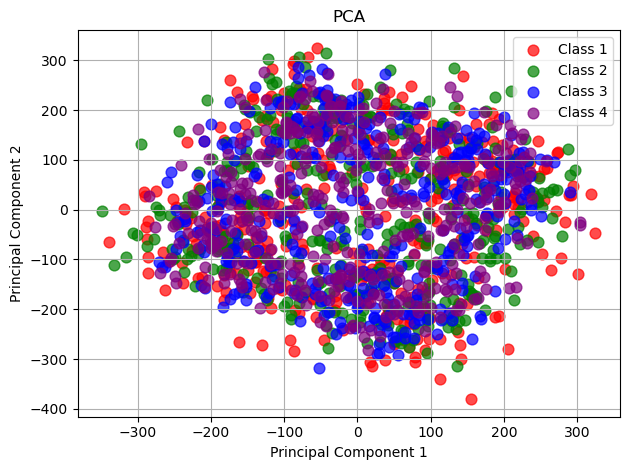

In [8]:
#dim2 = np.dot(dataX, vec)
dim2 = data_X_center @ vec[:, :2]

colors = ['red', 'green', 'blue', 'purple']

for i in range(4):
    pick = dataY == i
    plt.scatter(dim2[pick, 0], dim2[pick, 1], label=f'Class {i+1}', s=60, alpha=0.7, c=colors[i])
    
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# 載入 EfficientNet-B0 並進行遷移學習
model = efficientnet_b2(weights='IMAGENET1K_V1')

# 除錯：計算總參數張量數量
total_params = sum(1 for _ in model.parameters())
print(f"Total parameter tensors in EfficientNet-B0: {total_params}")

# 修改分類器
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# 凍結特徵提取器前 80% 的層，保留後 20% 和分類器可訓練
fine_tune_at = int(total_params * 0.8)  # 動態設置凍結點
print(f"Freezing up to  {fine_tune_at} parameter tensor")
layer_count = 0
for param in model.parameters():
    if layer_count < fine_tune_at:
        param.requires_grad = False
    else:
        param.requires_grad = True
    layer_count += 1

# 確保分類器層可訓練
for param in model.classifier.parameters():
    param.requires_grad = True

# 除錯：檢查可訓練參數
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")

# 檢查是否有可訓練參數
if trainable_params == 0:
    raise ValueError("No trainable parameters in the model. Adjust fine_tune_at")

print("\nModel Summary:")

summary(model, input_size=(batch_size, 3, img_height, img_width))

Total parameter tensors in EfficientNet-B0: 301
Freezing up to  240 parameter tensor
Number of trainable parameters: 4874872

Model Summary:


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [128, 4]                  --
├─Sequential: 1-1                                       [128, 1408, 25, 25]       --
│    └─Conv2dNormActivation: 2-1                        [128, 32, 400, 400]       --
│    │    └─Conv2d: 3-1                                 [128, 32, 400, 400]       (864)
│    │    └─BatchNorm2d: 3-2                            [128, 32, 400, 400]       (64)
│    │    └─SiLU: 3-3                                   [128, 32, 400, 400]       --
│    └─Sequential: 2-2                                  [128, 16, 400, 400]       --
│    │    └─MBConv: 3-4                                 [128, 16, 400, 400]       (1,448)
│    │    └─MBConv: 3-5                                 [128, 16, 400, 400]       (612)
│    └─Sequential: 2-3                                  [128, 24, 200, 200]       --
│    │    └─MBConv: 3-6                        

In [10]:
# 將模型移至設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
# 定義損失函數、優化器和學習率調度器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6, verbose=True)

In [12]:
# 訓練歷史視覺化函數
def history_plot(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.title('Training and validation accuracy')
    plt.plot(epochs, acc, 'red', label='Training acc')
    plt.plot(epochs, val_acc, 'blue', label='Validation acc')
    plt.legend()
    plt.savefig('accuracy_plot.png')
    plt.show()

    plt.figure()
    plt.title('Training and validation loss')
    plt.plot(epochs, loss, 'red', label='Training loss')
    plt.plot(epochs, val_loss, 'blue', label='Validation loss')
    plt.legend()
    plt.savefig('loss_plot.png')
    plt.show()

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=200):
    best_val_loss = float('inf')
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': [], 'weights': [], 'class_acc': [], 'conv1_weight':[]}
    best_model_wts = copy.deepcopy(model.state_dict())

    # 計算訓練集標籤分佈
    train_labels = np.concatenate([labels.numpy() for _, labels in train_loader])
    label_count = np.bincount(train_labels, minlength=4)  # 4 個類別

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # 訓練階段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.append(predicted.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        # 計算類別準確率
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        class_report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
        class_acc = [class_report[str(i)]['precision'] for i in range(4)]  # 4 個類別的 precision
        history['class_acc'].append(class_acc)

        # 記錄分類器權重
        weights = model.classifier[1].weight.cpu().detach().numpy()  # [4, 特徵數]
        history['weights'].append(weights.copy())

        # 驗證階段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            conv1_weights = model.features[0][0].weight.cpu().clone().detach().numpy()  # [32, 3, 3, 3]
            history['conv1_weight'].append(conv1_weights)
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Train Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')
        print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}')
        print(f'Class Accuracy: {class_acc}')

        # 儲存最佳模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_model.pt')
            print("Saving model to best_model.pt")

        # 更新學習率
        scheduler.step(val_loss)

    # 載入最佳模型權重
    model.load_state_dict(best_model_wts)
    return model, history


In [14]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=100)


Epoch 1/100
----------
Train Loss: 1.2398, Accuracy: 0.5069
Validation Loss: 1.2304, Accuracy: 0.5800
Class Accuracy: [0.8256880733944955, 0.5377643504531722, 0.39628482972136225, 0.44642857142857145]
Saving model to best_model.pt
Epoch 2/100
----------
Train Loss: 0.9101, Accuracy: 0.7244
Validation Loss: 0.9105, Accuracy: 0.7100
Class Accuracy: [0.8115577889447236, 0.71900826446281, 0.6333333333333333, 0.7190569744597249]
Saving model to best_model.pt
Epoch 3/100
----------
Train Loss: 0.6760, Accuracy: 0.7906
Validation Loss: 0.5808, Accuracy: 0.8250
Class Accuracy: [0.8023529411764706, 0.7519582245430809, 0.7164948453608248, 0.8861386138613861]
Saving model to best_model.pt
Epoch 4/100
----------
Train Loss: 0.5025, Accuracy: 0.8369
Validation Loss: 0.4124, Accuracy: 0.8400
Class Accuracy: [0.87, 0.7873417721518987, 0.7848101265822784, 0.9024390243902439]
Saving model to best_model.pt
Epoch 5/100
----------
Train Loss: 0.3978, Accuracy: 0.8775
Validation Loss: 0.3172, Accuracy: 0.8

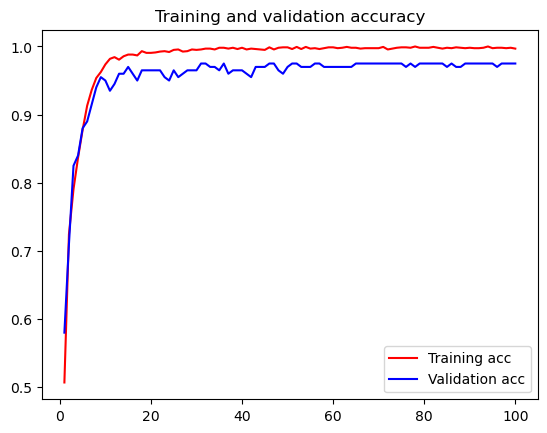

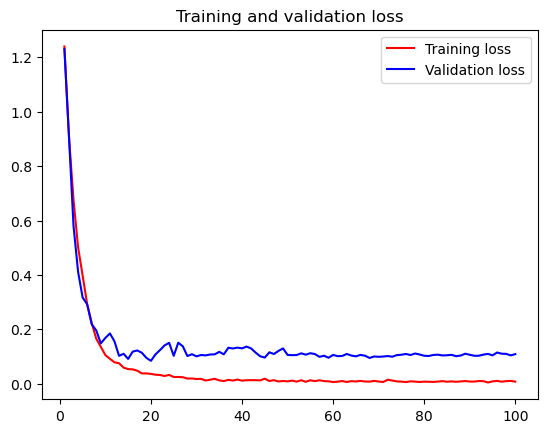

In [15]:
# 繪製訓練歷史
history_plot(history)

In [16]:
# 測試集評估
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.append(labels.item())
        y_pred.append(predicted.item())

# 分類報告
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=categories))
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 Score (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")


Classification Report:
              precision    recall  f1-score   support

      stage1       1.00      1.00      1.00        50
      stage2       0.96      0.96      0.96        50
      stage3       0.94      0.92      0.93        50
      stage4       0.96      0.98      0.97        50

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Accuracy: 0.9650
F1 Score (macro): 0.9649


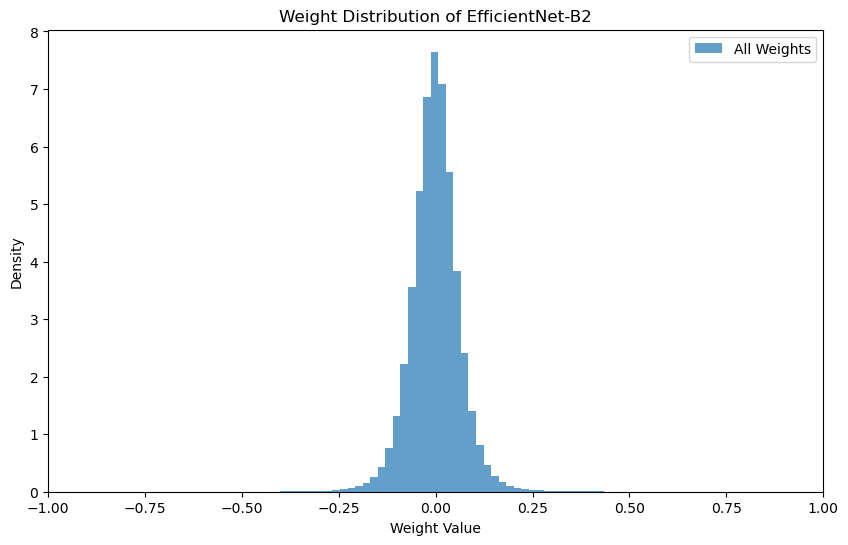

In [17]:
def plot_weight_distribution(model, layer_name=None):
    weights = []
    
    for name, param in model.named_parameters():
        # 過濾掉非權重的參數（如偏置或 BatchNorm 的參數）
        if 'weight' in name and (layer_name is None or layer_name in name):
            weights.append(param.cpu().detach().numpy().flatten())
    
    #展平
    all_weights = np.concatenate(weights)
    
    plt.figure(figsize=(10, 6))
    plt.hist(all_weights, bins=1000, density=True, alpha=0.7, label='All Weights')
    plt.xlabel('Weight Value')
    plt.ylabel('Density')
    plt.xlim([-1, 1])
    plt.title('Weight Distribution of EfficientNet-B2')
    plt.legend()
    plt.show()

plot_weight_distribution(model)

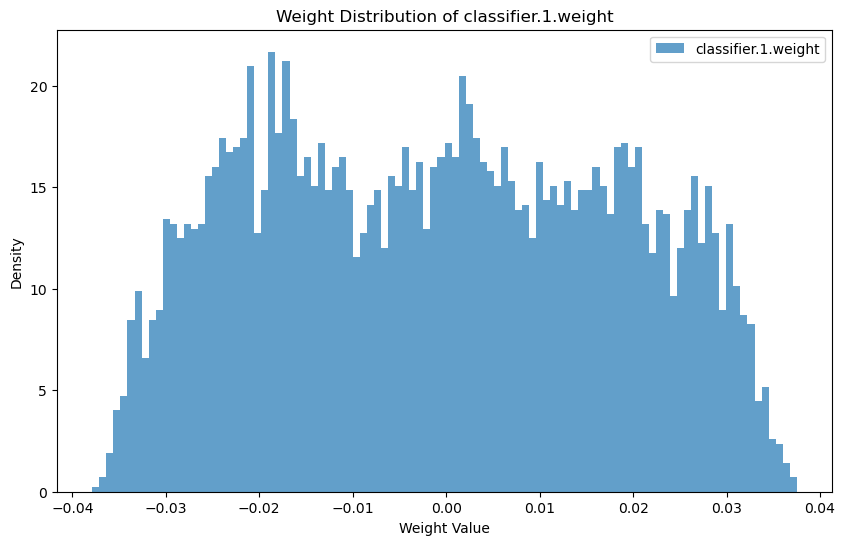

In [18]:
def plot_specific_layer_distribution(model, layer_name='classifier'):
    for name, param in model.named_parameters():
        if layer_name in name and 'weight' in name:
            weights = param.cpu().detach().numpy().flatten()
            plt.figure(figsize=(10, 6))
            plt.hist(weights, bins=100, density=True, alpha=0.7, label=f'{name}')
            plt.xlabel('Weight Value')
            plt.ylabel('Density')
            plt.title(f'Weight Distribution of {name}')
            plt.legend()
            plt.show()
plot_specific_layer_distribution(model, layer_name='classifier')

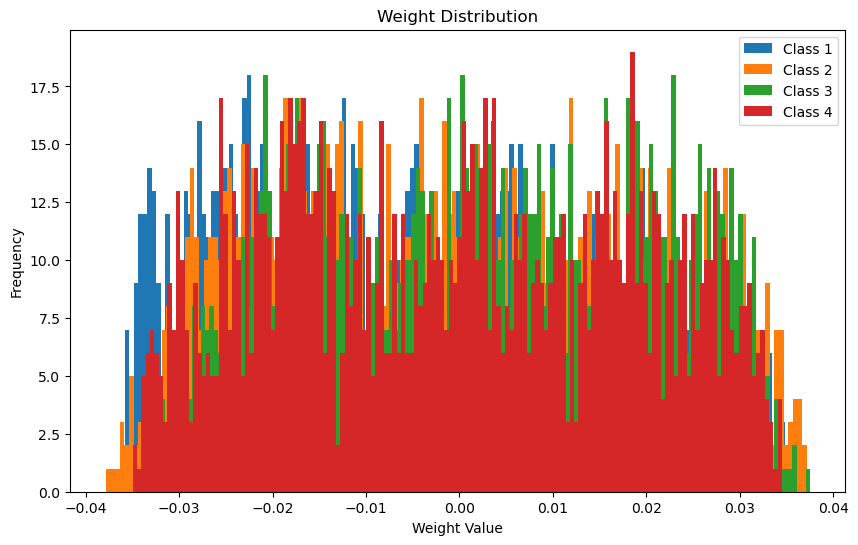

In [19]:
def plot_per_class_distribution(model, layer_name='classifier.1.weight'):
    for name, param in model.named_parameters():
        if name == layer_name:
            weights = param.cpu().detach().numpy()
            num_classes = weights.shape[0]
            
            plt.figure(figsize=(10, 6))
            for i in range(4): 
                class_weights = weights[i]
                plt.hist(class_weights, bins=150, label=f'Class {i+1}', alpha=1.0) 
                         
                
            plt.xlabel('Weight Value')
            plt.ylabel('Frequency')
            plt.title(f'Weight Distribution')
            plt.legend()
            plt.savefig('weight_distribution.jpg') 
            plt.show()
plot_per_class_distribution(model)


In [20]:
model.eval()
model = model.to(device)

In [21]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

In [22]:
model.features[5].register_forward_hook(get_activation('layer5'))
model.avgpool.register_forward_hook(get_activation('avgpool'))

In [23]:
train_features = []
train_labels = []
with torch.no_grad():
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.cpu().numpy().flatten()
        if not np.all(np.isin(labels, range(4))):
            print(f"Warning: Invalid labels in train batch: {labels}")
        _ = model(inputs)
        print(f"Train layer5 shape: {activations['layer5'].shape}")
        print(f"Train avgpool shape: {activations['avgpool'].shape}")
        out5 = F.avg_pool2d(activations['layer5'], activations['layer5'].size()[2:]).view(inputs.size(0), -1).cpu().numpy()
        out_avg = activations['avgpool'].view(inputs.size(0), -1).cpu().numpy()
        train_features.append([out5, out_avg])
        train_labels.append(labels)

Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size([128, 1408, 1, 1])
Train layer5 shape: torch.Size([128, 120, 50, 50])
Train avgpool shape: torch.Size

In [24]:
train_out5_flat = np.concatenate([f[0] for f in train_features], axis=0)
train_out_avg_flat = np.concatenate([f[1] for f in train_features], axis=0)
train_labels = np.concatenate(train_labels, axis=0)

In [25]:
# 標準化 features[5] 特徵
scaler5 = StandardScaler()
train_out5_flat = scaler5.fit_transform(train_out5_flat)

In [26]:

# 對 avgpool 特徵進行 LinearOperator PCA 降維到 100 維
avg_f = train_out_avg_flat  # 僅使用訓練集
avg_f_mean = np.mean(avg_f, axis=0)
avg_f_center = avg_f - avg_f_mean
n_avg = avg_f_center.shape[0]
def avg_matvec(x):
    return (avg_f_center.T @ (avg_f_center @ x)) / (n_avg - 1)

A_avg = LinearOperator((avg_f_center.shape[1], avg_f_center.shape[1]), matvec=avg_matvec)
val_avg, vec_avg = eigsh(A_avg, k=100, which='LM')

train_out_avg_flat = np.dot(train_out_avg_flat - avg_f_mean, vec_avg)

In [27]:
# 標準化降維後的 avgpool 特徵
scaler_avg = StandardScaler()
train_out_avg_flat = scaler_avg.fit_transform(train_out_avg_flat)

In [28]:
# 拼接特徵
train_f = np.concatenate([train_out5_flat, train_out_avg_flat], axis=1)

# 檢查形狀
print(f"Combined train feature shape: {train_f.shape}")
print(f"Train labels shape: {train_labels.shape}")

Combined train feature shape: (1600, 220)
Train labels shape: (1600,)


In [29]:
if train_f.shape[0] != train_labels.shape[0]:
    raise ValueError(f"Feature matrix has {train_f.shape[0]} samples, but labels have {train_labels.shape[0]} samples")

# 中心化特徵並應用 LinearOperator PCA（最終 2 維）
f_mean = np.mean(train_f, axis=0)
f_center = train_f - f_mean
n = f_center.shape[0]
def matvec(x):
    return (f_center.T @ (f_center @ x)) / (n - 1)

A = LinearOperator((f_center.shape[1], f_center.shape[1]), matvec=matvec)
val, vec = eigsh(A, k=2, which='LM')

In [30]:
explained_variance_ratio = val / np.sum(val)
print(f"Cumulative explained variance ratio for top-2 PCs: {np.sum(explained_variance_ratio[:2]):.4f}")

Cumulative explained variance ratio for top-2 PCs: 1.0000


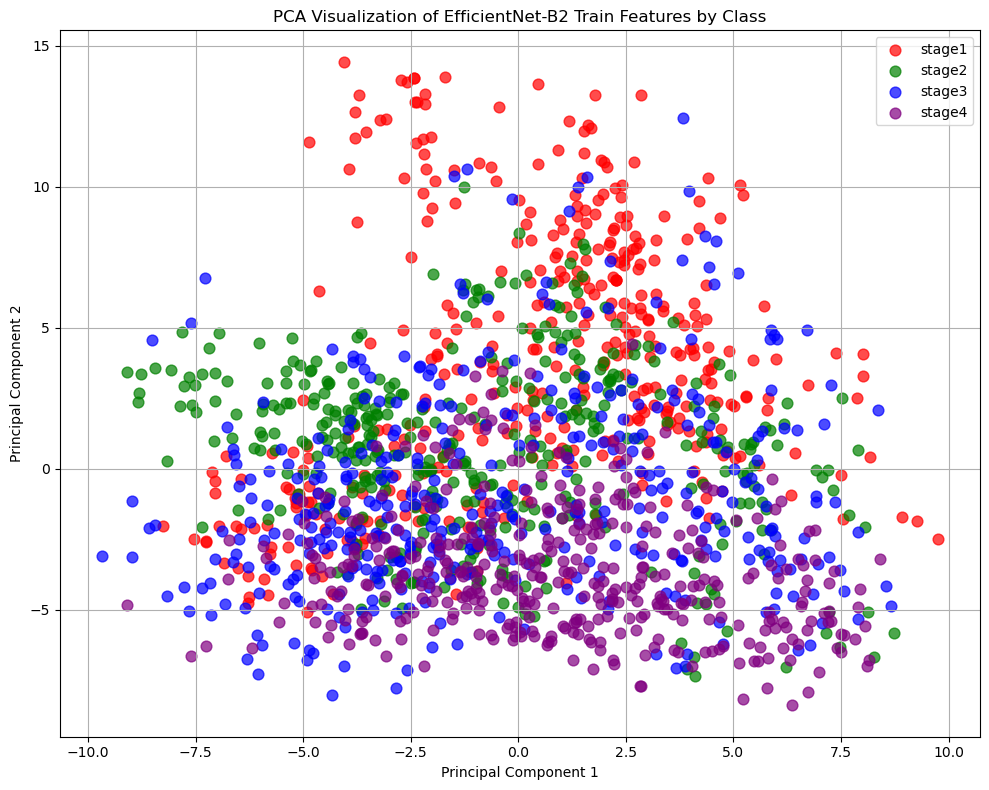

In [31]:
dim2 = np.dot(train_f, vec)  # 僅對訓練集進行投影

# 繪製訓練集散點圖，按類別使用不同顏色
plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue', 'purple']
class_names = ['stage1', 'stage2', 'stage3', 'stage4']

for i in range(4):
    pick = train_labels == i  # 選擇類別 i 的樣本
    plt.scatter(dim2[pick, 0], dim2[pick, 1], c=colors[i], alpha = 0.7, s=60, marker='o', label=class_names[i])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of EfficientNet-B2 Train Features by Class")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存圖像
plt.savefig('pca_train_by_class.png')
plt.show()

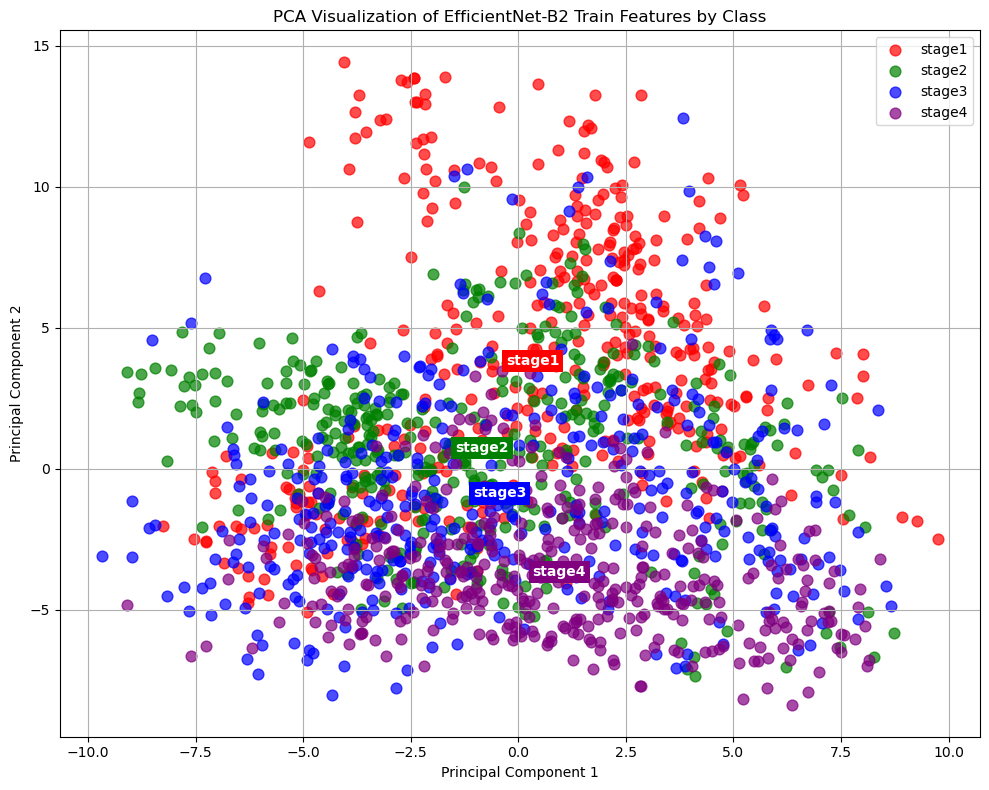

In [32]:
plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue', 'purple']
class_names = ['stage1', 'stage2', 'stage3', 'stage4']

for i in range(4):
    pick = train_labels == i
    x = dim2[pick, 0]
    y = dim2[pick, 1]
    plt.scatter(x, y, c=colors[i], alpha=0.7, s=60, marker='o', label=class_names[i])

    # 類別中心
    cx = x.mean()
    cy = y.mean()

    # 類別名稱文字框（顏色同類別顏色，文字為白）
    plt.text(cx, cy, class_names[i],
             fontsize=10, weight='bold', ha='center', va='center',
             color='white',
             bbox=dict(facecolor=colors[i], edgecolor='none', pad=3))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of EfficientNet-B2 Train Features by Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_train_colored_labels.png')
plt.show()
